In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zoomride_case_study.csv")

df.head()

,booking_id,customer_id,driver_id,time_of_day,pickup_area,drop_area,ride_status,estimated_time,actual_time,fare_amount,driver_rating,customer_rating,vehicle_type,day_of_week,surge_multiplier
0,0,18322,NaN,afternoon,Area_11,Area_8,no_driver_found,25,NaN,182.0,NaN,3.92,sedan,Fri,1.0
1,1,12558,1560.0,night,Area_6,Area_2,cancelled_by_customer,25,NaN,240.0,3.81,3.86,sedan,Thu,1.0
2,2,18433,1600.0,night,Area_15,Area_19,completed,16,15.0,386.0,3.63,3.03,sedan,Mon,1.2
3,3,11021,1001.0,morning,Area_15,Area_7,completed,16,20.0,114.0,3.15,4.33,sedan,Sat,2.0
4,4,11016,1251.0,evening,Area_18,Area_12,completed,6,12.0,349.0,3.32,4.14,sedan,Fri,1.5


In [ ]:
df.describe()

,booking_id,customer_id,driver_id,estimated_time,actual_time,fare_amount,driver_rating,customer_rating,surge_multiplier
count,20000.000000,20000.000000,18024.000000,20000.000000,11978.000000,18502.000000,18024.000000,20000.000000,20000.000000
mean,9999.500000,15020.689250,1499.933367,17.001800,22.581817,289.270025,3.751845,3.997063,1.240380
std,5773.647028,2885.515158,287.770807,7.190096,8.903518,120.868904,0.726101,0.579624,0.316494
min,0.000000,10000.000000,1000.000000,5.000000,2.000000,80.000000,2.500000,3.000000,1.000000
25%,4999.750000,12526.000000,1252.000000,11.000000,16.000000,185.000000,3.120000,3.490000,1.000000
50%,9999.500000,15063.500000,1498.000000,17.000000,23.000000,290.000000,3.750000,3.990000,1.200000
75%,14999.250000,17517.000000,1747.000000,23.000000,29.000000,393.000000,4.380000,4.500000,1.500000
max,19999.000000,19999.000000,1999.000000,29.000000,43.000000,499.000000,5.000000,5.000000,2.000000


In [ ]:
df.shape

(20000, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   booking_id        20000 non-null  int64  
 1   customer_id       20000 non-null  int64  
 2   driver_id         18024 non-null  float64
 3   time_of_day       20000 non-null  object 
 4   pickup_area       20000 non-null  object 
 5   drop_area         20000 non-null  object 
 6   ride_status       20000 non-null  object 
 7   estimated_time    20000 non-null  int64  
 8   actual_time       11978 non-null  float64
 9   fare_amount       18502 non-null  float64
 10  driver_rating     18024 non-null  float64
 11  customer_rating   20000 non-null  float64
 12  vehicle_type      20000 non-null  object 
 13  day_of_week       20000 non-null  object 
 14  surge_multiplier  20000 non-null  float64
dtypes: float64(6), int64(3), object(6)
memory usage: 2.3+ MB


In [ ]:
print(df.isnull().sum())

booking_id             0
customer_id            0
driver_id           1976
time_of_day            0
pickup_area            0
drop_area              0
ride_status            0
estimated_time         0
actual_time         8022
fare_amount         1498
driver_rating       1976
customer_rating        0
vehicle_type           0
day_of_week            0
surge_multiplier       0
dtype: int64


In [ ]:
df[['actual_time']].describe()

,actual_time
count,11978.000000
mean,22.581817
std,8.903518
min,2.000000
25%,16.000000
50%,23.000000
75%,29.000000
max,43.000000


In [ ]:
''' Actual Time
actual_time is missing when 'no_driver_found','cancelled_by_driver','cancelled_by_customers'
NULL - ride is not happen
now we fill - 0 (no time taken)'''


df['actual_time'] = df['actual_time'].fillna(0)
df

,booking_id,customer_id,driver_id,time_of_day,pickup_area,drop_area,ride_status,estimated_time,actual_time,fare_amount,driver_rating,customer_rating,vehicle_type,day_of_week,surge_multiplier
0,0,18322,NaN,afternoon,Area_11,Area_8,no_driver_found,25,0.0,182.0,NaN,3.92,sedan,Fri,1.0
1,1,12558,1560.0,night,Area_6,Area_2,cancelled_by_customer,25,0.0,240.0,3.81,3.86,sedan,Thu,1.0
2,2,18433,1600.0,night,Area_15,Area_19,completed,16,15.0,386.0,3.63,3.03,sedan,Mon,1.2
3,3,11021,1001.0,morning,Area_15,Area_7,completed,16,20.0,114.0,3.15,4.33,sedan,Sat,2.0
4,4,11016,1251.0,evening,Area_18,Area_12,completed,6,12.0,349.0,3.32,4.14,sedan,Fri,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,18178,1991.0,evening,Area_14,Area_17,completed,15,22.0,317.0,3.82,4.98,mini,Fri,1.0
19996,19996,18090,1736.0,night,Area_18,Area_20,completed,10,20.0,481.0,3.73,3.78,sedan,Wed,2.0
19997,19997,17998,1548.0,morning,Area_2,Area_18,cancelled_by_driver,6,0.0,165.0,3.64,4.51,sedan,Tue,1.0
19998,19998,17882,1752.0,night,Area_6,Area_3,completed,16,15.0,197.0,4.72,3.77,sedan,Fri,1.0


In [ ]:
df[['driver_rating']].describe()

,driver_rating
count,18024.000000
mean,3.751845
std,0.726101
min,2.500000
25%,3.120000
50%,3.750000
75%,4.380000
max,5.000000


In [ ]:
'''Driver Rating is null when 'No_Driver_found'
Reason:'''#driver_rating is given by customer when ride is completed.in this case no driver is assigned to the ride and that's why ride is not completed and customer cannot rate that's the reason driver_rating is missing
#NULL - unclear
#0 - means no rating available

df['driver_rating'] = df['driver_rating'].fillna(0)

In [ ]:
df[['driver_id']].describe()

,driver_id
count,18024.000000
mean,1499.933367
std,287.770807
min,1000.000000
25%,1252.000000
50%,1498.000000
75%,1747.000000
max,1999.000000


In [ ]:
''' DATA CLEANING '''
# driver_id is null because no driver is assigned to that ride
#no driver accepted the ride
#no driver was available nearby
# or failed to find a driver
#when:
#ride_status = "no_driver_found"
#Then:
#driver_id = NULL
# both driver_id and ride_status telling same meaning
# now i fill driver_id with value "No driver" where id is null
df['driver_id'] = df['driver_id'].fillna("No Driver")

In [ ]:
df['driver_id'].value_counts()

,count
driver_id,
No Driver,1976
1876.0,32
1423.0,31
1601.0,30
1451.0,30
...,...
1197.0,8
1193.0,7
1165.0,7


In [ ]:
df[['fare_amount']].describe()

,fare_amount
count,18502.000000
mean,289.270025
std,120.868904
min,80.000000
25%,185.000000
50%,290.000000
75%,393.000000
max,499.000000


In [ ]:
'''fare amount is null when ride-status is 'cancelled by driver','cancelled by customers
Reason:''' # fare_amount is generated only if the ride is completed
# INSIGHT::“cancelled rides genereted zero revenue AND also it represents lost opportunity to generate revenue”

df['fare_amount'] = df['fare_amount'].fillna(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   booking_id        20000 non-null  int64  
 1   customer_id       20000 non-null  int64  
 2   driver_id         20000 non-null  object 
 3   time_of_day       20000 non-null  object 
 4   pickup_area       20000 non-null  object 
 5   drop_area         20000 non-null  object 
 6   ride_status       20000 non-null  object 
 7   estimated_time    20000 non-null  int64  
 8   actual_time       20000 non-null  float64
 9   fare_amount       20000 non-null  float64
 10  driver_rating     20000 non-null  float64
 11  customer_rating   20000 non-null  float64
 12  vehicle_type      20000 non-null  object 
 13  day_of_week       20000 non-null  object 
 14  surge_multiplier  20000 non-null  float64
dtypes: float64(5), int64(3), object(7)
memory usage: 2.3+ MB


ride_status
completed                11978
cancelled_by_driver       3051
cancelled_by_customer     2995
no_driver_found           1976
Name: count, dtype: int64


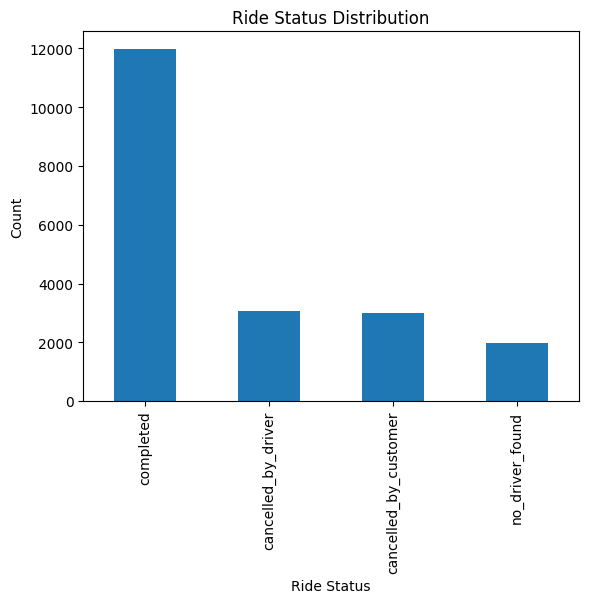

In [ ]:
# It shows which problem is biggest like completed,cancelled by driver,cancelled by customer,no driver
status_counts = df['ride_status'].value_counts()
print(status_counts)

status_counts.plot(kind='bar')
plt.title("Ride Status Distribution")
plt.xlabel("Ride Status")
plt.ylabel("Count")
plt.show()

ride_status  cancelled_by_customer  cancelled_by_driver  completed  \
time_of_day                                                          
afternoon                      749                  794       2974   
evening                        885                  901       3658   
morning                        734                  758       2940   
night                          627                  598       2406   

ride_status  no_driver_found  completion_rate  
time_of_day                                    
afternoon                524         0.589962  
evening                  561         0.609159  
morning                  516         0.594179  
night                    375         0.600599  


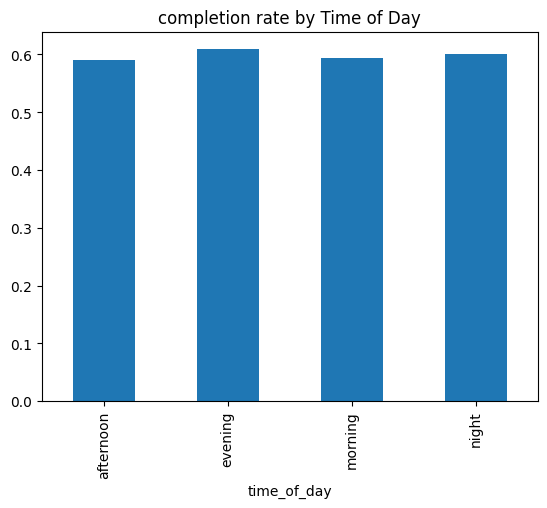

In [ ]:
#  it shows at which time of the day rides are successfully completed and at which time problem occured to complete rides

time_ana = df.groupby(['time_of_day', 'ride_status']).size().unstack()

time_ana['completion_rate'] = time_ana['completed'] / time_ana.sum(axis=1)

print(time_ana)

time_ana['completion_rate'].plot(kind='bar')
plt.title("completion rate by Time of Day")
plt.show()

ride_status  cancelled_by_customer  cancelled_by_driver  completed  \
day_of_week                                                          
Fri                            441                  457       1704   
Mon                            414                  425       1697   
Sat                            432                  429       1720   
Sun                            434                  434       1753   
Thu                            460                  424       1681   
Tue                            417                  451       1722   
Wed                            397                  431       1701   

ride_status  no_driver_found  completion_rate  
day_of_week                                    
Fri                      279         0.591461  
Mon                      307         0.596905  
Sat                      267         0.603933  
Sun                      276         0.605109  
Thu                      263         0.594413  
Tue                      286     

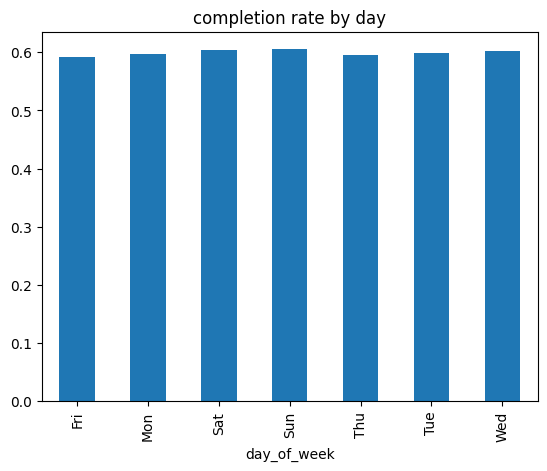

In [ ]:
#day wise analysis
day_als=df.groupby(['day_of_week','ride_status']).size().unstack()
day_als['completion_rate']=day_als['completed'] / day_als.sum(axis=1)
print(day_als)
day_als['completion_rate'].plot(kind='bar')
plt.title('completion rate by day')
plt.show()


In [ ]:
# high demand areas
print("Top demand areas")
print(df['pickup_area'].value_counts().head(10))

Top demand areas
pickup_area
Area_8     1047
Area_1     1039
Area_14    1037
Area_5     1037
Area_2     1034
Area_18    1024
Area_19    1009
Area_16    1009
Area_7     1002
Area_4     1001
Name: count, dtype: int64


In [ ]:
# Problem area(No driver)
no_driver_areas=df[df['ride_status'] == 'no_driver_found']['pickup_area'].value_counts().head(10)
print("no driver problem areas")
no_driver_areas
#Insight: where driver is missing

no driver problem areas


,count
pickup_area,
Area_18,127
Area_2,114
Area_19,110
Area_4,109
Area_9,108
Area_6,107
Area_17,105
Area_5,102
Area_16,100


In [ ]:
#Driver Analysis
bad_driver=df.groupby('driver_id')['ride_status'].value_counts().unstack().fillna(0)
bad_driver['total']= bad_driver.sum(axis=1)
bad_driver['cancel_rate'] = bad_driver.get('cancelled_by_driver',0) / bad_driver['total']
print("Drivers who cancelled high rides")
bad_driver.sort_values('cancel_rate', ascending=False).head(10)

Drivers who cancelled high rides


ride_status,cancelled_by_customer,cancelled_by_driver,completed,no_driver_found,total,cancel_rate
driver_id,,,,,,
1787.0,0.0,5.0,5.0,0.0,10.0,0.500000
1279.0,0.0,8.0,11.0,0.0,19.0,0.421053
1953.0,0.0,5.0,7.0,0.0,12.0,0.416667
1981.0,3.0,7.0,7.0,0.0,17.0,0.411765
1025.0,2.0,6.0,7.0,0.0,15.0,0.400000
1718.0,0.0,6.0,9.0,0.0,15.0,0.400000
1644.0,1.0,6.0,8.0,0.0,15.0,0.400000
1702.0,2.0,8.0,10.0,0.0,20.0,0.400000
1141.0,3.0,9.0,11.0,0.0,23.0,0.391304


In [ ]:
#customer Analysis
bad_customer=df.groupby('customer_id')['ride_status'].value_counts().unstack().fillna(0)
bad_customer['total']= bad_driver.sum(axis=1)
bad_customer['cancel_rate'] = bad_driver.get('cancelled_by_customer',0) / bad_customer['total']
print("Customers who cancelled high rides")
bad_customer.sort_values('cancel_rate', ascending=False).head(10)

Customers who cancelled high rides


ride_status,cancelled_by_customer,cancelled_by_driver,completed,no_driver_found,total,cancel_rate
customer_id,,,,,,
10000,0.0,0.0,1.0,1.0,NaN,NaN
10002,0.0,1.0,0.0,0.0,NaN,NaN
10003,0.0,0.0,3.0,1.0,NaN,NaN
10004,0.0,0.0,1.0,0.0,NaN,NaN
10005,0.0,0.0,4.0,1.0,NaN,NaN
10006,2.0,0.0,0.0,0.0,NaN,NaN
10007,0.0,2.0,0.0,0.0,NaN,NaN
10008,0.0,0.0,2.0,0.0,NaN,NaN
10009,0.0,0.0,5.0,0.0,NaN,NaN


In [ ]:
customer_stats=df.groupby('customer_id')['ride_status'].value_counts().unstack().fillna(0)
customer_stats['total_rides'] = customer_stats.sum(axis=1)

customer_stats['customer_cancel_rate'] = (
    customer_stats.get('cancelled_by_customer', 0) / customer_stats['total_rides']
)
customer_stats['completion_rate'] = (customer_stats.get('completed', 0) / customer_stats['total_rides'])
bad_customers = customer_stats[
    (customer_stats['customer_cancel_rate'] > 0.5) &
    (customer_stats['total_rides'] > 5)
]
bad_customers = bad_customers.sort_values(by='customer_cancel_rate', ascending=False)

print("Top Bad Customers:")
bad_customers.head()


Top Bad Customers:


ride_status,cancelled_by_customer,cancelled_by_driver,completed,no_driver_found,total_rides,customer_cancel_rate,completion_rate
customer_id,,,,,,,
12225,4.0,0.0,1.0,1.0,6.0,0.666667,0.166667


In [ ]:
#Revenue Analysiss
total_revenue = df['fare_amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 5352074.0


In [ ]:
fail_rides = df[df['ride_status'] != 'completed']
print("Failed Rides:", len(fail_rides))

Failed Rides: 8022


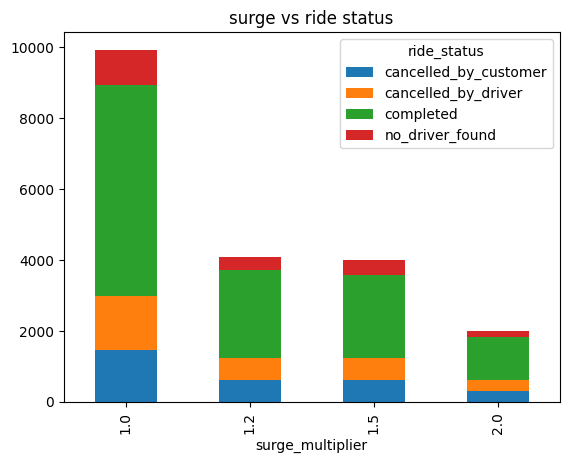

In [ ]:
#To find surge is working or not
surge_als=df.groupby('surge_multiplier')['ride_status'].value_counts().unstack()
surge_als.plot(kind='bar',stacked=True)
plt.title("surge vs ride status")
plt.show()

In [ ]:
#which vehicle type has more failure
vehicle_als = df.groupby('vehicle_type')['ride_status'].value_counts().unstack()

print(vehicle_als.head())

ride_status   cancelled_by_customer  cancelled_by_driver  completed  \
vehicle_type                                                          
mini                           1065                  992       3920   
sedan                           977                 1010       4042   
suv                             953                 1049       4016   

ride_status   no_driver_found  
vehicle_type                   
mini                      644  
sedan                     643  
suv                       689  


In [ ]:
# Delay analysis
#Insights:customer dissatisfaction happend because of delay in ride
completed_rides=df[df['ride_status'] == 'completed'].copy()
completed_rides['delay'] = completed_rides['actual_time'] - completed_rides['estimated_time']
print(completed_rides['delay'].describe())

count    11978.000000
mean         5.534563
std          5.214944
min         -3.000000
25%          1.000000
50%          5.000000
75%         10.000000
max         14.000000
Name: delay, dtype: float64


In [ ]:
# count    11978 rides are delayed from 20,000 rides
# mean         5.534563 Average delay for ride
# std          5.214944 delay is fluctuating
# min         -3.000000 ride is completed before expected time
# 25%          1.000000 25 % of rides delay is <= 1 minute
# 50%          5.000000 50 % of rides delay is <=5 minute
# 75%         10.000000 75 % of rides delay is <=10 minute this means 25% rides  delay > 10 minute big problem
# max         14.000000 some customers are waiting for 14 minute Biggest problem


In [ ]:
total = len(df)

completed = len(df[df['ride_status'] == 'completed'])
driver_cancel = len(df[df['ride_status'] == 'cancelled_by_driver'])
customer_cancel = len(df[df['ride_status'] == 'cancelled_by_customer'])
no_driver = len(df[df['ride_status'] == 'no_driver_found'])


print("completion rate:", completed/total)
print("drivr cancel rate:", driver_cancel/total)
print("custmer cancel rate:", customer_cancel/total)
print("no Driver found rate:", no_driver/total)

completion rate: 0.5989
drivr cancel rate: 0.15255
custmer cancel rate: 0.14975
no Driver found rate: 0.0988


In [ ]:
from scipy.stats import chi2_contingency

# contingency table
table = pd.crosstab(df['surge_multiplier'], df['ride_status'])

chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

P-value: 0.49699633738090176


In [ ]:
#p_value is 0.4969 > 0.05 that means there is no significant relationship between the surge pricing and ride_status